<a href="https://colab.research.google.com/github/juanpajaro/aprendizaje_profundo_salud_puj_2026/blob/main/Los_cimientos_de_redes_neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.26.0 which is incompatible.


In [2]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

##**La primera mirada a redes neuronales**

In [4]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
train_images.shape

(60000, 28, 28)

In [6]:
len(train_labels)

60000

In [7]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [8]:
test_images.shape

(10000, 28, 28)

In [9]:
len(test_labels)

10000

In [10]:
test_labels

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [11]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

In [12]:
print(model)

<Sequential name=sequential, built=False>


In [13]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [14]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [15]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9241 - loss: 0.2695
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9677 - loss: 0.1110
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9793 - loss: 0.0708
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9850 - loss: 0.0511
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9896 - loss: 0.0361


In [16]:
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


array([1.3680346e-07, 9.3169334e-08, 3.1903091e-05, 5.8886444e-04,
       2.6091065e-09, 6.6700892e-07, 4.3703100e-11, 9.9934918e-01,
       7.1386955e-07, 2.8531904e-05], dtype=float32)

In [20]:
test_digits.shape

(10, 784)

In [21]:
type(test_digits)

numpy.ndarray

In [22]:
predictions[0].argmax()

np.int64(7)

In [23]:
predictions[0][7]

np.float32(0.9993492)

In [24]:
test_labels[0]

np.uint8(7)

In [25]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"test_acc: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9796 - loss: 0.0671
test_acc: 0.9796000123023987


##**Representacion de los datos para redes neuronales**

In [35]:
import numpy as np
x = np.array(12)
x

array(12)

In [36]:
x.ndim

0

In [37]:
x = np.array([12, 3, 6, 14, 7])
x

array([12,  3,  6, 14,  7])

In [38]:
print(x.ndim)
print(x.shape)

1
(5,)


In [31]:
x = np.array([[5, 78, 2, 34, 0],
             [6, 79, 3, 35, 1],
             [7, 80, 4, 36, 2]])
x

array([[ 5, 78,  2, 34,  0],
       [ 6, 79,  3, 35,  1],
       [ 7, 80,  4, 36,  2]])

In [32]:
print(x.ndim)
print(x.shape)

2
(3, 5)


In [33]:
x = np.array([[[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]]])
print(x.ndim)
print(x.shape)

3
(3, 3, 5)


###**intepretación de atributos**

In [40]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [41]:
train_images.ndim

3

In [42]:
train_images.shape

(60000, 28, 28)

In [43]:
train_images.dtype

dtype('uint8')

60000


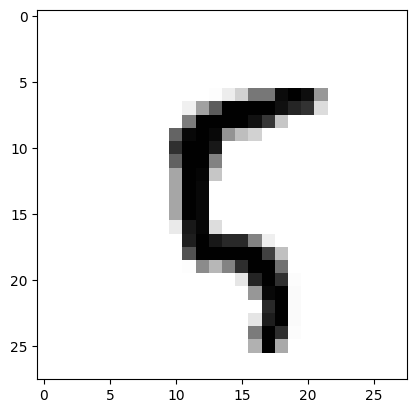

In [48]:
import matplotlib.pyplot as plt

print(len(train_images))
digit = train_images[100]
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

In [50]:
train_labels[100]

np.uint8(5)

###**manipulacion de tensores usando numpy**

In [51]:
my_slice = train_images[10:100]
my_slice.shape

(90, 28, 28)

In [52]:
my_slice = train_images[10:100, :, :]
my_slice.shape

(90, 28, 28)

In [53]:
my_slice = train_images[10:100, 0:28, 0:28]
my_slice.shape

(90, 28, 28)

In [56]:
my_slice = train_images[:, 14:, 14:]
my_slice.shape

(60000, 14, 14)

In [57]:
my_slice = train_images[:, 7:-7, 7:-7]
my_slice.shape

(60000, 14, 14)

###**Lotes o batches**

In [62]:
batch = train_images[:128]
print(batch.shape)

(128, 28, 28)


In [63]:
batch = train_images[128:256]
print(batch.shape)

(128, 28, 28)


In [64]:
n = 3
batch = train_images[128 * n : 128 * (n + 1)]
print(batch.shape)

(128, 28, 28)
